In [1]:
import numpy as np
import pandas as pd
import sys

from pathlib import Path
from typing import Tuple

module_path = str(Path("..").resolve())
if module_path not in sys.path:
    sys.path.append(module_path)

import utils.data_io as data_io
import utils.vis as vis

from config_handlers.eval_handler import EvalHandler
from config_handlers.rk_handler import RKHandler

## Setup

In [2]:
rk_hdl = RKHandler()
eval_hdl = EvalHandler()

model_list = rk_hdl.get_model_list()
""" Skipping MiniGPT4 as we have incomplete data. """
model_list.remove("minigpt4")
rk_hdl.set_curr_model(model_list[0])
ds_list = rk_hdl.get_ds_list()

all_ds = ds_list * len(model_list)
all_models = model_list * len(ds_list)
all_models.sort()

MC_DATASETS = ["seed", "vqav2"]
OPEN_DATASETS = ["llava-bench", "mmbench"]

CHARTS_DIR = Path("behaviour_charts")
data_io.make_dir(CHARTS_DIR)

[Errno 17] File exists: 'behaviour_charts'


In [3]:
def load_triples_data(emb_model="mpnet") -> Tuple[dict, dict]:
    samples = {m: {ds: {} for ds in ds_list} for m in model_list}
    summaries = {m: {ds: {} for ds in ds_list} for m in model_list}
    for model, ds in zip(all_models, all_ds):
        base_fp = Path("raw_stats", f"sim_triples_{emb_model}")
        samples[model][ds] = data_io.load_json(
            base_fp.joinpath(model, ds, "samples.json")
        )
        summaries[model][ds] = data_io.load_json(
            base_fp.joinpath(model, ds, "summary.json")
        )

    return samples, summaries

Loading eval responses for correlation between triple similarity and performance

In [4]:
def load_eval_responses():
    data = {m: {ds: {}} for m in model_list for ds in ds_list}
    for model, ds in zip(all_models, all_ds):
        eval_hdl.set_curr_model(model)
        eval_hdl.set_curr_ds(ds)
        data[model][ds] = data_io.load_json(Path("..", eval_hdl.get_eval_path()))
    return data


eval_data = load_eval_responses()

In [5]:
emb_model = "mpnet"  # granite
samples, summaries = load_triples_data(emb_model=emb_model)

In [6]:
# Check the range of cosine similarity values obtained
for m, ds in zip(all_models, all_ds):
    print("=" * 70)
    print(f"Ranges for {m.upper()} on {ds.upper()}")
    print("\t\t = Min. = \t = Max. = \t = Avg. = \t Support")
    # First, get sample-level averages
    mes = [v["avg"] for v in samples[m][ds].values()]
    min_mes = np.min(mes).item()
    max_mes = np.max(mes).item()
    avg_mes = np.mean(mes).item()
    print(
        f"Sample-level \t {min_mes:.4f} \t {max_mes:.4f} \t {avg_mes:.4f} \t {len(mes)}"
    )

    # Then, consider the individual triples
    mes = [t["cosine"] for v in samples[m][ds].values() for t in v["measures"]]
    min_mes = np.min(mes).item()
    max_mes = np.max(mes).item()
    print(f"Triple-level \t {min_mes:.4f} \t {max_mes:.4f} \t ------ \t {len(mes)}")

    print("-" * 70)
    negs = [m for m in mes if m <= 0]
    print(f"Num. negative triple similarities: {len(negs)}/{len(mes)}")
print("=" * 70)

Ranges for INTERNVL2 on LLAVA-BENCH
		 = Min. = 	 = Max. = 	 = Avg. = 	 Support
Sample-level 	 0.2014 	 0.6784 	 0.4527 	 58
Triple-level 	 0.0301 	 0.9140 	 ------ 	 553
----------------------------------------------------------------------
Num. negative triple similarities: 0/553
Ranges for INTERNVL2 on MMBENCH
		 = Min. = 	 = Max. = 	 = Avg. = 	 Support
Sample-level 	 0.1587 	 0.8050 	 0.4948 	 139
Triple-level 	 -0.0282 	 1.0000 	 ------ 	 1233
----------------------------------------------------------------------
Num. negative triple similarities: 1/1233
Ranges for INTERNVL2 on SEED
		 = Min. = 	 = Max. = 	 = Avg. = 	 Support
Sample-level 	 0.1496 	 0.9559 	 0.4744 	 150
Triple-level 	 -0.0557 	 1.0000 	 ------ 	 1163
----------------------------------------------------------------------
Num. negative triple similarities: 2/1163
Ranges for INTERNVL2 on VQAV2
		 = Min. = 	 = Max. = 	 = Avg. = 	 Support
Sample-level 	 0.2376 	 0.9209 	 0.5478 	 150
Triple-level 	 0.0343 	 1.0000 	 -

## Pepare main dataframe

We have very few triple similarities that are slightly negative, let's clip those to `0.0` when creating the dataframe.

In [7]:
df = pd.DataFrame()
for model, ds in zip(all_models, all_ds):
    for q_idx in samples[model][ds]:
        # We have very few cosine similarities that are sligthly negative.
        # Clip those to 0.0. They are basically irrelevant.
        avg_cosine = (
            samples[model][ds][q_idx]["avg"]
            if samples[model][ds][q_idx]["avg"] > 0.0
            else 0.0
        )
        rows = []
        """
        Take care of empty measures
            - Qwen2.5-VL + VQAv2: '120162001', '333538005'
            - ShareGPT4V + SEED: '2358'
        """
        if len(samples[model][ds][q_idx]["measures"]) > 0:
            for m in samples[model][ds][q_idx]["measures"]:
                rows.append(
                    {
                        "question_id": str(q_idx),
                        "model": model,
                        "dataset": ds,
                        "sample_cosine": avg_cosine,
                        "sk_triple": m["sk_triple"],
                        "rk_triple": m["rk_triple"],
                        "triple_cosine": m["cosine"] if m["cosine"] > 0.0 else 0.0,
                    }
                )
        else:
            rows.append(
                {
                    "question_id": str(q_idx),
                    "model": model,
                    "dataset": ds,
                    "sample_cosine": avg_cosine,
                    "sk_triple": None,
                    "rk_triple": None,
                    "triple_cosine": 0.0,
                }
            )

        temp_df = pd.DataFrame.from_records(rows)
        df = pd.concat([df, temp_df], ignore_index=True)

Checking number of triples to make sure nothing got lost

In [8]:
# Check the number of triples in 'samples' vs 'df'
# Note that the following are correct since we have no similar triples
#   QWEN2_5_VL on VQAV2: 		 260 --> 262 	 Missing: -2
#   SHAREGPT4V on SEED: 		 230 --> 231 	 Missing: -1
for model, ds in zip(all_models, all_ds):
    df_count = len(df[(df["model"] == model) & (df["dataset"] == ds)])
    samples_count = len([t for m in samples[model][ds].values() for t in m["measures"]])
    print(
        f"{model.upper()} on {ds.upper()}: \t\t {samples_count} --> {df_count} \t Missing: {samples_count - df_count}"
    )

INTERNVL2 on LLAVA-BENCH: 		 553 --> 553 	 Missing: 0
INTERNVL2 on MMBENCH: 		 1233 --> 1233 	 Missing: 0
INTERNVL2 on SEED: 		 1163 --> 1163 	 Missing: 0
INTERNVL2 on VQAV2: 		 934 --> 934 	 Missing: 0
LLAVA-1.6 on LLAVA-BENCH: 		 265 --> 265 	 Missing: 0
LLAVA-1.6 on MMBENCH: 		 745 --> 745 	 Missing: 0
LLAVA-1.6 on SEED: 		 786 --> 786 	 Missing: 0
LLAVA-1.6 on VQAV2: 		 879 --> 879 	 Missing: 0
QWEN2_5_VL on LLAVA-BENCH: 		 446 --> 446 	 Missing: 0
QWEN2_5_VL on MMBENCH: 		 544 --> 544 	 Missing: 0
QWEN2_5_VL on SEED: 		 491 --> 491 	 Missing: 0
QWEN2_5_VL on VQAV2: 		 260 --> 262 	 Missing: -2
SHAREGPT4V on LLAVA-BENCH: 		 259 --> 259 	 Missing: 0
SHAREGPT4V on MMBENCH: 		 612 --> 612 	 Missing: 0
SHAREGPT4V on SEED: 		 230 --> 231 	 Missing: -1
SHAREGPT4V on VQAV2: 		 43 --> 43 	 Missing: 0


In [9]:
df.head()

,question_id,model,dataset,sample_cosine,sk_triple,rk_triple,triple_cosine
0,0,internvl2,llava-bench,0.483854,"{'from_concept': 'tree', 'relationship': 'grow...","{'from_concept': 'volcanic tuff cone', 'relati...",0.440655
1,0,internvl2,llava-bench,0.483854,"{'from_concept': 'shoreline', 'relationship': ...","{'from_concept': 'volcanic tuff cone', 'relati...",0.566356
2,0,internvl2,llava-bench,0.483854,"{'from_concept': 'vegetation', 'relationship':...","{'from_concept': 'coastal area', 'relationship...",0.597013
3,0,internvl2,llava-bench,0.483854,"{'from_concept': 'shoreline', 'relationship': ...","{'from_concept': 'coastal area', 'relationship...",0.405063
4,0,internvl2,llava-bench,0.483854,"{'from_concept': 'shoreline', 'relationship': ...","{'from_concept': 'beach', 'relationship': 'is ...",0.517302


In [10]:
len(df)

9446

Add model performance to dataframe

In [11]:
# Data preparation
eval_data_clean = {model: {ds: [] for ds in eval_data[model]} for model in eval_data}
for model, ds in zip(all_models, all_ds):
    if ds in OPEN_DATASETS:
        ranges = list(eval_data[model][ds]["ranges"].keys())
        for r in ranges:
            eval_data_clean[model][ds].extend(
                [
                    {"question_id": int(d["question_id"]), "f1": d["measures"]["f1"]}
                    for d in eval_data[model][ds]["ranges"][r]
                ]
            )
        # Parse remaning, invalid responses
        eval_data_clean[model][ds].extend(
            [
                {"question_id": int(d["question_id"]), "f1": 0.0}
                for d in eval_data[model][ds]["invalid_resp"]
            ]
        )
    elif ds in MC_DATASETS:
        # Parse correct_resp and wrong_resp
        eval_data_clean[model][ds].extend(
            [
                {"question_id": int(d["question_id"]), "correct": 1}
                for d in eval_data[model][ds]["correct_resp"]
            ]
        )
        eval_data_clean[model][ds].extend(
            [
                {"question_id": int(d["question_id"]), "correct": 0}
                for d in eval_data[model][ds]["wrong_resp"]
            ]
        )
        # Parse remaning, invalid responses
        eval_data_clean[model][ds].extend(
            [
                {"question_id": int(d["question_id"]), "correct": 0}
                for d in eval_data[model][ds]["invalid_resp"]
            ]
        )
    else:
        print("Error")

In [12]:
def get_outcome(row, eval_data_clean):
    data = next(
        (
            e
            for e in eval_data_clean[row["model"]][row["dataset"]]
            if str(e["question_id"]) == row["question_id"]
        ),
        None,
    )
    return data


df["oe_outcome"] = df.apply(
    lambda x: get_outcome(x, eval_data_clean)["f1"]
    if x["dataset"] in OPEN_DATASETS
    else None,
    axis=1,
)
df["mc_outcome"] = df.apply(
    lambda x: get_outcome(x, eval_data_clean)["correct"]
    if x["dataset"] in MC_DATASETS
    else None,
    axis=1,
)
df.head()

,question_id,model,dataset,sample_cosine,sk_triple,rk_triple,triple_cosine,oe_outcome,mc_outcome
0,0,internvl2,llava-bench,0.483854,"{'from_concept': 'tree', 'relationship': 'grow...","{'from_concept': 'volcanic tuff cone', 'relati...",0.440655,0.792572,NaN
1,0,internvl2,llava-bench,0.483854,"{'from_concept': 'shoreline', 'relationship': ...","{'from_concept': 'volcanic tuff cone', 'relati...",0.566356,0.792572,NaN
2,0,internvl2,llava-bench,0.483854,"{'from_concept': 'vegetation', 'relationship':...","{'from_concept': 'coastal area', 'relationship...",0.597013,0.792572,NaN
3,0,internvl2,llava-bench,0.483854,"{'from_concept': 'shoreline', 'relationship': ...","{'from_concept': 'coastal area', 'relationship...",0.405063,0.792572,NaN
4,0,internvl2,llava-bench,0.483854,"{'from_concept': 'shoreline', 'relationship': ...","{'from_concept': 'beach', 'relationship': 'is ...",0.517302,0.792572,NaN


In [13]:
df[df["dataset"] == "seed"].head()

,question_id,model,dataset,sample_cosine,sk_triple,rk_triple,triple_cosine,oe_outcome,mc_outcome
1786,3151,internvl2,seed,0.448732,"{'from_concept': 'counter', 'relationship': 'i...","{'from_concept': 'bar counter', 'relationship'...",0.563838,NaN,1.0
1787,3151,internvl2,seed,0.448732,"{'from_concept': 'counter', 'relationship': 'i...","{'from_concept': 'bar counter', 'relationship'...",0.544087,NaN,1.0
1788,3151,internvl2,seed,0.448732,"{'from_concept': 'lamps', 'relationship': 'abo...","{'from_concept': 'bar counter', 'relationship'...",0.581275,NaN,1.0
1789,3151,internvl2,seed,0.448732,"{'from_concept': 'counter', 'relationship': 'i...","{'from_concept': 'bar counter', 'relationship'...",0.492896,NaN,1.0
1790,3151,internvl2,seed,0.448732,"{'from_concept': 'counter', 'relationship': 'i...","{'from_concept': 'bar counter', 'relationship'...",0.455433,NaN,1.0


In [14]:
for model, ds in zip(all_models, all_ds):
    subdf = df[(df["model"] == model) & (df["dataset"] == ds)]
    print(f"{model.upper()} on {ds.upper()}: {len(subdf['question_id'].unique())}")

INTERNVL2 on LLAVA-BENCH: 58
INTERNVL2 on MMBENCH: 139
INTERNVL2 on SEED: 150
INTERNVL2 on VQAV2: 150
LLAVA-1.6 on LLAVA-BENCH: 44
LLAVA-1.6 on MMBENCH: 133
LLAVA-1.6 on SEED: 129
LLAVA-1.6 on VQAV2: 142
QWEN2_5_VL on LLAVA-BENCH: 56
QWEN2_5_VL on MMBENCH: 139
QWEN2_5_VL on SEED: 150
QWEN2_5_VL on VQAV2: 150
SHAREGPT4V on LLAVA-BENCH: 49
SHAREGPT4V on MMBENCH: 135
SHAREGPT4V on SEED: 109
SHAREGPT4V on VQAV2: 21


Current dataframe
- `question_id`
- `model`
- `dataset`
- `sample_cosine`: sample-level, avg similarity
- `sk_triple`
- `rk_triple`
- `triple_cosine`: triple-level, similarity
- `oe_outcome`: BERTScore F1
- `mc_outcome`: correct (1.0) or incorrect (0.0)

### Add behaviour types

Simple equal 3-way split

In [15]:
prec = 6
n_split = 3
step = round(1 / n_split, prec)
simple_split = {
    idx + 1: {"start": round(val.item(), prec), "end": round(val.item() + step, prec)}
    for idx, val in enumerate(np.linspace(0, 1, n_split + 1))
    if idx < n_split
}

# Swap ranges for types 1 and 3
temp = simple_split[1]
simple_split[1] = simple_split[3]
simple_split[3] = temp

print(simple_split)

{1: {'start': 0.666667, 'end': 1.0}, 2: {'start': 0.333333, 'end': 0.666666}, 3: {'start': 0.0, 'end': 0.333333}}


In [16]:
def get_behaviour_type(sim_val, ranges):
    temp = float(round(sim_val, prec))
    for idx, r in ranges.items():
        if temp >= r["start"] and temp <= r["end"]:
            return idx
    print("Error; returning None")
    return None

In [17]:
analysis_type = None
df["sample_type"] = df.apply(
    lambda x: get_behaviour_type(x["sample_cosine"], simple_split), axis=1
)
df["triple_type"] = df.apply(
    lambda x: get_behaviour_type(x["triple_cosine"], simple_split), axis=1
)
df.head()

,question_id,model,dataset,sample_cosine,sk_triple,rk_triple,triple_cosine,oe_outcome,mc_outcome,sample_type,triple_type
0,0,internvl2,llava-bench,0.483854,"{'from_concept': 'tree', 'relationship': 'grow...","{'from_concept': 'volcanic tuff cone', 'relati...",0.440655,0.792572,NaN,2,2
1,0,internvl2,llava-bench,0.483854,"{'from_concept': 'shoreline', 'relationship': ...","{'from_concept': 'volcanic tuff cone', 'relati...",0.566356,0.792572,NaN,2,2
2,0,internvl2,llava-bench,0.483854,"{'from_concept': 'vegetation', 'relationship':...","{'from_concept': 'coastal area', 'relationship...",0.597013,0.792572,NaN,2,2
3,0,internvl2,llava-bench,0.483854,"{'from_concept': 'shoreline', 'relationship': ...","{'from_concept': 'coastal area', 'relationship...",0.405063,0.792572,NaN,2,2
4,0,internvl2,llava-bench,0.483854,"{'from_concept': 'shoreline', 'relationship': ...","{'from_concept': 'beach', 'relationship': 'is ...",0.517302,0.792572,NaN,2,2


Prepare counts for plotting

In [18]:
def get_counts(df, ranges, aggregation="plot"):
    if aggregation == "model":
        counts = {m: {ds: {} for ds in ds_list} for m in model_list}
    elif aggregation == "type":
        counts = {
            idx: {m: {ds: 0 for ds in ds_list} for m in model_list} for idx in ranges
        }
    elif aggregation == "plot":
        counts = {idx: {ds: [] for ds in ds_list} for idx in ranges}
    else:
        print("aggregation not recognised")
        return

    for idx, r in ranges.items():
        for m, ds in zip(all_models, all_ds):
            # Get counts
            count = len(
                df[
                    (df["dataset"] == ds)
                    & (df["model"] == m)
                    & (round(df["triple_cosine"], prec) >= r["start"])
                    & (round(df["triple_cosine"], prec) <= r["end"])
                ]
            )

            if aggregation == "model":
                counts[m][ds][idx] = count
            elif aggregation == "type":
                counts[idx][m][ds] = count
            elif aggregation == "plot":
                counts[idx][ds].append(count)
            else:
                print("aggregation not recognised")
                return

    return counts

In [19]:
counts_type = get_counts(df, simple_split, aggregation="type")
counts_plot = get_counts(df, simple_split, aggregation="plot")

In [20]:
counts_plot

{1: {'llava-bench': [62, 37, 22, 31],
  'mmbench': [238, 129, 161, 131],
  'seed': [168, 114, 55, 59],
  'vqav2': [218, 189, 77, 14]},
 2: {'llava-bench': [333, 154, 159, 149],
  'mmbench': [719, 402, 297, 380],
  'seed': [700, 445, 216, 127],
  'vqav2': [499, 454, 107, 24]},
 3: {'llava-bench': [158, 74, 265, 79],
  'mmbench': [276, 214, 86, 101],
  'seed': [295, 227, 220, 45],
  'vqav2': [217, 236, 78, 5]}}

In [21]:
# Just double-checking
for model, ds in zip(all_models, all_ds):
    curr = 0
    for t in counts_type:
        curr += counts_type[t][model][ds]
    print(f"{model.upper()} on {ds.upper()}: {curr}")

INTERNVL2 on LLAVA-BENCH: 553
INTERNVL2 on MMBENCH: 1233
INTERNVL2 on SEED: 1163
INTERNVL2 on VQAV2: 934
LLAVA-1.6 on LLAVA-BENCH: 265
LLAVA-1.6 on MMBENCH: 745
LLAVA-1.6 on SEED: 786
LLAVA-1.6 on VQAV2: 879
QWEN2_5_VL on LLAVA-BENCH: 446
QWEN2_5_VL on MMBENCH: 544
QWEN2_5_VL on SEED: 491
QWEN2_5_VL on VQAV2: 262
SHAREGPT4V on LLAVA-BENCH: 259
SHAREGPT4V on MMBENCH: 612
SHAREGPT4V on SEED: 231
SHAREGPT4V on VQAV2: 43


In [ ]:
if analysis_type:
    out_path = Path(CHARTS_DIR, f"triples_type_{analysis_type}_{emb_model}.pdf")
else:
    out_path = Path(CHARTS_DIR, f"triples_type_{emb_model}.pdf")

vis.plot_behaviour_counts(counts_plot, out_path, to_skip="minigpt4")

Skipping data for minigpt4


/Users/lorenzocorti/Developer/mllm_diagnosis/utils/vis.py:458: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


Sample data and save to file for manual inspection. Goal: tweak thresholds for cosine similarity

In [23]:
behaviour_types = df["triple_type"].unique().tolist()
behaviour_types.sort()
max_sample = 150

for btype in behaviour_types:
    print(f"Processing behaviours of type {btype}.")
    dict_save = {m: {d: {} for d in ds_list} for m in model_list}
    for model, ds in zip(all_models, all_ds):
        print(f"> Processing {model} on {ds}.")
        subdf = df[
            (df["triple_type"] == btype)
            & (df["model"] == model)
            & (df["dataset"] == ds)
        ]
        n_sample = max_sample if len(subdf) >= max_sample else len(subdf)
        subdf = subdf.sample(n=n_sample, replace=False, random_state=42)
        print(f"Sampling of {n_sample} behaviours of type {btype}... Got {len(subdf)}.")
        for _, row in subdf.iterrows():
            q_idx = row["question_id"]
            if q_idx not in dict_save[model][ds]:
                dict_save[model][ds][q_idx] = []
            dict_save[model][ds][q_idx].append(
                row.filter(
                    ["sk_triple", "rk_triple", "triple_cosine", "triple_type"]
                ).to_dict()
            )
    data_io.save_json(dict_save, Path("raw_stats", f"behaviours_type_{btype}.json"))

Processing behaviours of type 1.
> Processing internvl2 on llava-bench.
Sampling of 62 behaviours of type 1... Got 62.
> Processing internvl2 on mmbench.
Sampling of 150 behaviours of type 1... Got 150.
> Processing internvl2 on seed.
Sampling of 150 behaviours of type 1... Got 150.
> Processing internvl2 on vqav2.
Sampling of 150 behaviours of type 1... Got 150.
> Processing llava-1.6 on llava-bench.
Sampling of 37 behaviours of type 1... Got 37.
> Processing llava-1.6 on mmbench.
Sampling of 129 behaviours of type 1... Got 129.
> Processing llava-1.6 on seed.
Sampling of 114 behaviours of type 1... Got 114.
> Processing llava-1.6 on vqav2.
Sampling of 150 behaviours of type 1... Got 150.
> Processing qwen2_5_vl on llava-bench.
Sampling of 22 behaviours of type 1... Got 22.
> Processing qwen2_5_vl on mmbench.
Sampling of 150 behaviours of type 1... Got 150.
> Processing qwen2_5_vl on seed.
Sampling of 55 behaviours of type 1... Got 55.
> Processing qwen2_5_vl on vqav2.
Sampling of 77 

Strict split after manual inspection

In [24]:
strict_split = {
    1: {"start": 0.75, "end": 1.0},
    2: {"start": 0.333334, "end": 0.749999},
    3: {"start": 0.0, "end": 0.333333},
}
print(strict_split)

{1: {'start': 0.75, 'end': 1.0}, 2: {'start': 0.333334, 'end': 0.749999}, 3: {'start': 0.0, 'end': 0.333333}}


In [25]:
analysis_type = "strict"
df["sample_type"] = df.apply(
    lambda x: get_behaviour_type(x["sample_cosine"], strict_split), axis=1
)
df["triple_type"] = df.apply(
    lambda x: get_behaviour_type(x["triple_cosine"], strict_split), axis=1
)

In [26]:
counts_type = get_counts(df, strict_split, aggregation="type")
counts_plot = get_counts(df, strict_split, aggregation="plot")

In [27]:
if analysis_type:
    out_path = Path(CHARTS_DIR, f"triple_types_{analysis_type}_{emb_model}.pdf")
else:
    out_path = Path(CHARTS_DIR, f"triple_types_{emb_model}.pdf")

vis.plot_behaviour_counts(counts_plot, out_path, to_skip="minigpt4")

Skipping data for minigpt4


/Users/lorenzocorti/Developer/mllm_diagnosis/utils/vis.py:458: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


# Analyse correlation between similarity values and model performance 

In [28]:
from scipy.stats import pearsonr, spearmanr
from sklearn.feature_selection import mutual_info_regression

In [29]:
df.head()

,question_id,model,dataset,sample_cosine,sk_triple,rk_triple,triple_cosine,oe_outcome,mc_outcome,sample_type,triple_type
0,0,internvl2,llava-bench,0.483854,"{'from_concept': 'tree', 'relationship': 'grow...","{'from_concept': 'volcanic tuff cone', 'relati...",0.440655,0.792572,NaN,2,2
1,0,internvl2,llava-bench,0.483854,"{'from_concept': 'shoreline', 'relationship': ...","{'from_concept': 'volcanic tuff cone', 'relati...",0.566356,0.792572,NaN,2,2
2,0,internvl2,llava-bench,0.483854,"{'from_concept': 'vegetation', 'relationship':...","{'from_concept': 'coastal area', 'relationship...",0.597013,0.792572,NaN,2,2
3,0,internvl2,llava-bench,0.483854,"{'from_concept': 'shoreline', 'relationship': ...","{'from_concept': 'coastal area', 'relationship...",0.405063,0.792572,NaN,2,2
4,0,internvl2,llava-bench,0.483854,"{'from_concept': 'shoreline', 'relationship': ...","{'from_concept': 'beach', 'relationship': 'is ...",0.517302,0.792572,NaN,2,2


In [30]:
corr_input = {m: {ds: {} for ds in ds_list} for m in model_list}
for model, ds in zip(all_models, all_ds):
    subdf = df[(df["model"] == model) & (df["dataset"] == ds)]
    corr_input[model][ds]["cosine"] = subdf["sample_cosine"].to_list()
    if ds in MC_DATASETS:
        corr_input[model][ds]["outcome"] = subdf["mc_outcome"].to_list()
    elif ds in OPEN_DATASETS:
        corr_input[model][ds]["outcome"] = subdf["oe_outcome"].to_list()
    else:
        print("Error")

Visualising the data

In [31]:
# import matplotlib.pyplot as plt

# out_scatter = Path("scatter_plots")
# data_io.make_dir(out_scatter)

# for model, ds in zip(all_models, all_ds):
#     plt.scatter(
#         corr_input[model][ds]["cosine"],
#         corr_input[model][ds]["outcome"],
#         alpha=0.6,
#     )
#     plt.xlabel("Cosine similarity")
#     if ds in OPEN_DATASETS:
#         plt.ylabel("BERTScore-F1")
#     else:
#         plt.ylabel("Accuracy")
#     plt.title(f"{model} x {ds}")
#     plt.savefig(out_scatter.joinpath(f"{model}_{ds}.pdf"))
#     plt.close()

Pearson and Spearman correlations

In [32]:
print("\t\t\t\t == Pearson rho == \t == Spearman r ==")
alt = 0
for model, ds in zip(all_models, all_ds):
    rho, pval_rho = pearsonr(
        corr_input[model][ds]["cosine"], corr_input[model][ds]["outcome"]
    )
    r, pval_r = spearmanr(
        corr_input[model][ds]["cosine"], corr_input[model][ds]["outcome"]
    )
    print(
        f"{model.upper()} + {ds}        \t {rho:.3f} (p: {pval_rho:.3f})  \t {r:.3f} (p: {pval_r:.3f})"
    )
    alt += 1
    if alt % len(ds_list) == 0:
        print("-" * 80)

				 == Pearson rho == 	 == Spearman r ==
INTERNVL2 + llava-bench        	 -0.049 (p: 0.252)  	 -0.122 (p: 0.004)
INTERNVL2 + mmbench        	 -0.044 (p: 0.124)  	 -0.063 (p: 0.026)
INTERNVL2 + seed        	 0.106 (p: 0.000)  	 0.115 (p: 0.000)
INTERNVL2 + vqav2        	 0.161 (p: 0.000)  	 0.124 (p: 0.000)
--------------------------------------------------------------------------------
LLAVA-1.6 + llava-bench        	 0.076 (p: 0.216)  	 0.014 (p: 0.818)
LLAVA-1.6 + mmbench        	 -0.043 (p: 0.238)  	 -0.064 (p: 0.082)
LLAVA-1.6 + seed        	 -0.028 (p: 0.433)  	 -0.007 (p: 0.846)
LLAVA-1.6 + vqav2        	 -0.037 (p: 0.272)  	 -0.044 (p: 0.193)
--------------------------------------------------------------------------------
QWEN2_5_VL + llava-bench        	 0.073 (p: 0.125)  	 0.077 (p: 0.104)
QWEN2_5_VL + mmbench        	 0.134 (p: 0.002)  	 0.085 (p: 0.048)
QWEN2_5_VL + seed        	 -0.071 (p: 0.117)  	 -0.072 (p: 0.111)
QWEN2_5_VL + vqav2        	 0.167 (p: 0.007)  	 0.178 (p

-> *p-values indicate inconclusive values for the most part*

**Mutual Information**
- Is higher than 0 in general
- This implementation uses kNN and measures MI with natural logarithms and it increases very slowly
- MI > 2 might be uncommon in practice
- Problem: our sample sizes are kinda small... need to double-check for possible biases and overestimations (since we have values that are very high)

In [33]:
def bootstrap_mi(X, Y, k, n_boot=500, do_perm=False, random_state=0):
    rng = np.random.RandomState(random_state)
    n = len(X)
    mi_boot = []
    for _ in range(n_boot):
        idx = rng.randint(0, n, size=n)
        Xb, Yb = X[idx], Y[idx]
        if do_perm:
            rng.shuffle(Yb)
        mi_boot.append(
            mutual_info_regression(
                Xb, Yb, n_neighbors=k, random_state=random_state
            ).item()
        )
    mi_boot = np.array(mi_boot)
    mean = np.mean(mi_boot)
    low, high = np.percentile(mi_boot, [2.5, 97.5])  # <- 95% CI, 2 sides
    return mean.item(), low.item(), high.item()


k_vals = [3, 5, 7, 10, 15, 20, 30]
n_boot = 1000
mi_data = {
    model: {
        ds: {
            "means_obs": [],
            "lows_obs": [],
            "highs_obs": [],
            "means_perm": [],
            "lows_perm": [],
            "highs_perm": [],
            "pvals": [],
        }
        for ds in ds_list
    }
    for model in model_list
}

for model, ds in zip(all_models, all_ds):
    print(f"{model.upper()} on {ds.upper()}")
    x = np.array(corr_input[model][ds]["cosine"]).reshape(-1, 1)
    y = np.array(corr_input[model][ds]["outcome"])
    for k in k_vals:
        m_obs, lo_obs, hi_obs = bootstrap_mi(x, y, k, n_boot=n_boot)
        m_perm, lo_perm, hi_perm = bootstrap_mi(x, y, k, n_boot=n_boot, do_perm=True)
        pval = (np.sum(m_perm >= m_obs) + 1) / (n_boot + 1)

        # Update data
        mi_data[model][ds]["means_obs"].append(m_obs)
        mi_data[model][ds]["lows_obs"].append(lo_obs)
        mi_data[model][ds]["highs_obs"].append(hi_obs)
        mi_data[model][ds]["means_perm"].append(m_perm)
        mi_data[model][ds]["lows_perm"].append(lo_perm)
        mi_data[model][ds]["highs_perm"].append(hi_perm)
        mi_data[model][ds]["pvals"].append(pval)

INTERNVL2 on LLAVA-BENCH
INTERNVL2 on MMBENCH
INTERNVL2 on SEED
INTERNVL2 on VQAV2
LLAVA-1.6 on LLAVA-BENCH
LLAVA-1.6 on MMBENCH
LLAVA-1.6 on SEED
LLAVA-1.6 on VQAV2
QWEN2_5_VL on LLAVA-BENCH
QWEN2_5_VL on MMBENCH
QWEN2_5_VL on SEED
QWEN2_5_VL on VQAV2
SHAREGPT4V on LLAVA-BENCH
SHAREGPT4V on MMBENCH
SHAREGPT4V on SEED
SHAREGPT4V on VQAV2


Print MI

In [34]:
print("\t\t\t = K =\t= MI observed =\t= Perm p-value =")
for model, ds in zip(all_models, all_ds):
    if ds in OPEN_DATASETS:
        print(f"{model.upper()} + {ds.upper()}")
        for k, mean, p in zip(
            k_vals, mi_data[model][ds]["means_obs"], mi_data[model][ds]["pvals"]
        ):
            print(f"\t\t\t  {k} \t {mean:.3f} \t\t {p:.3f}")

			 = K =	= MI observed =	= Perm p-value =
INTERNVL2 + LLAVA-BENCH
			  3 	 3.880 		 0.001
			  5 	 3.612 		 0.001
			  7 	 3.187 		 0.001
			  10 	 2.415 		 0.001
			  15 	 1.356 		 0.001
			  20 	 0.928 		 0.001
			  30 	 0.633 		 0.001
INTERNVL2 + MMBENCH
			  3 	 3.738 		 0.001
			  5 	 3.439 		 0.001
			  7 	 2.933 		 0.001
			  10 	 2.082 		 0.001
			  15 	 1.157 		 0.001
			  20 	 0.727 		 0.001
			  30 	 0.334 		 0.001
LLAVA-1.6 + LLAVA-BENCH
			  3 	 3.109 		 0.001
			  5 	 2.652 		 0.001
			  7 	 2.102 		 0.001
			  10 	 1.255 		 0.001
			  15 	 0.508 		 0.001
			  20 	 0.306 		 0.001
			  30 	 0.144 		 0.001
LLAVA-1.6 + MMBENCH
			  3 	 3.243 		 0.001
			  5 	 2.732 		 0.001
			  7 	 2.196 		 0.001
			  10 	 1.494 		 0.001
			  15 	 0.860 		 0.001
			  20 	 0.631 		 0.001
			  30 	 0.434 		 0.001
QWEN2_5_VL + LLAVA-BENCH
			  3 	 3.651 		 0.001
			  5 	 3.222 		 0.001
			  7 	 2.683 		 0.001
			  10 	 1.845 		 0.001
			  15 	 0.820 		 0.001
			  20 	 0.384 		 0.001
			  30 	

Plot MI

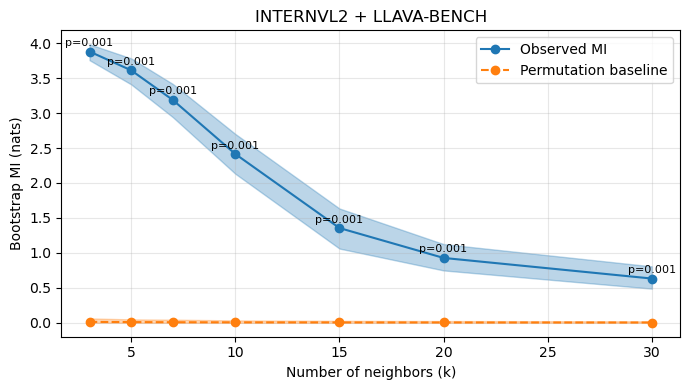

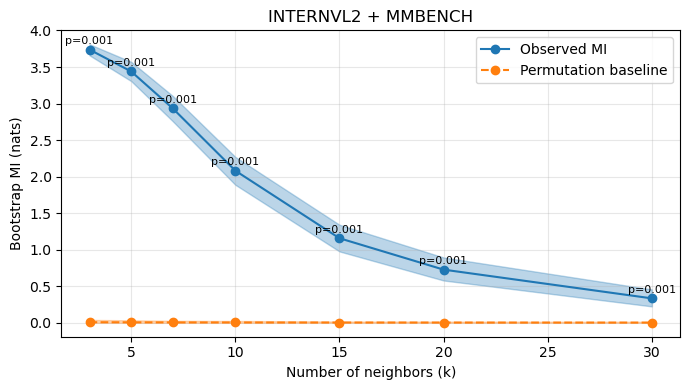

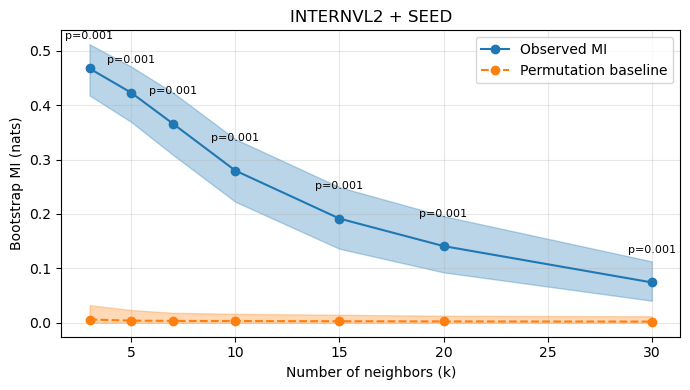

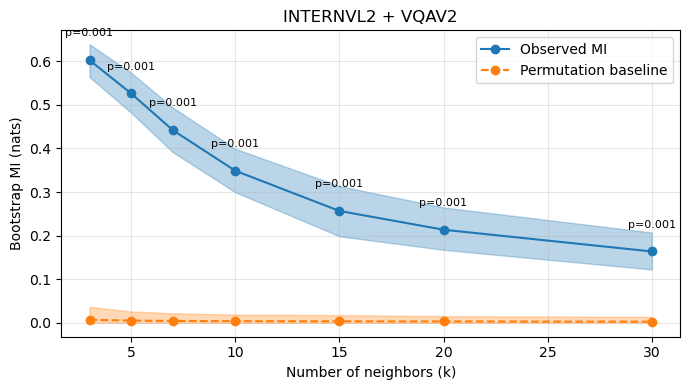

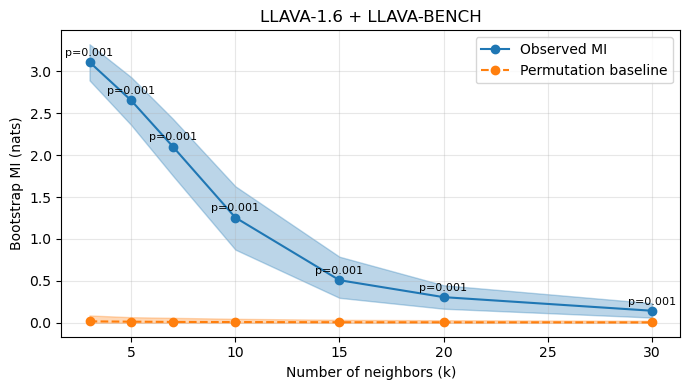

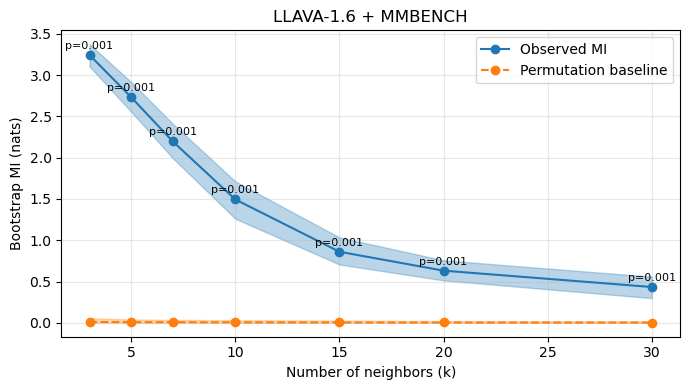

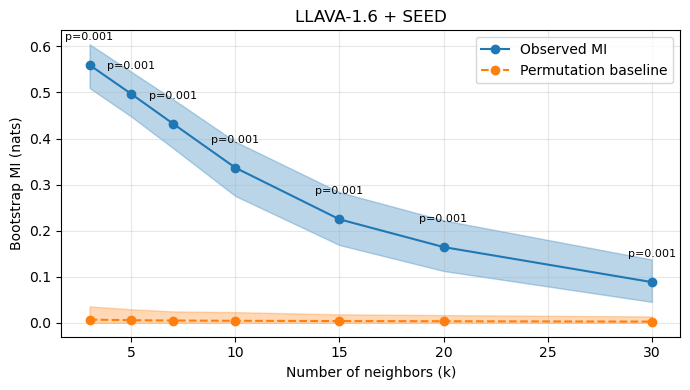

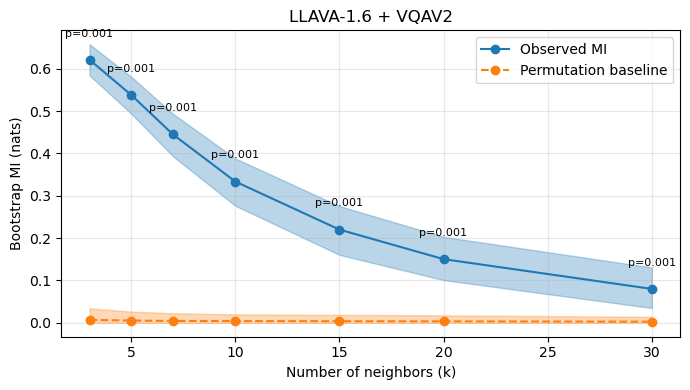

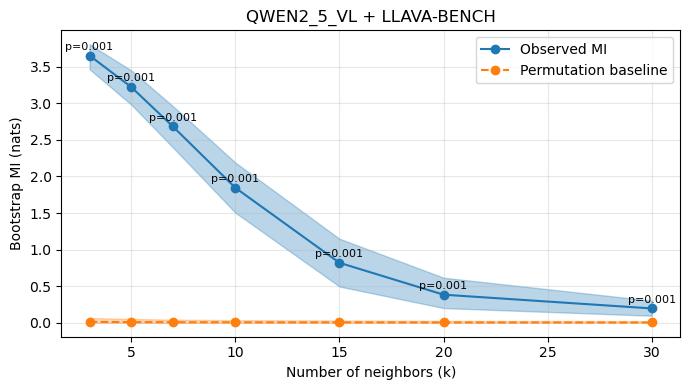

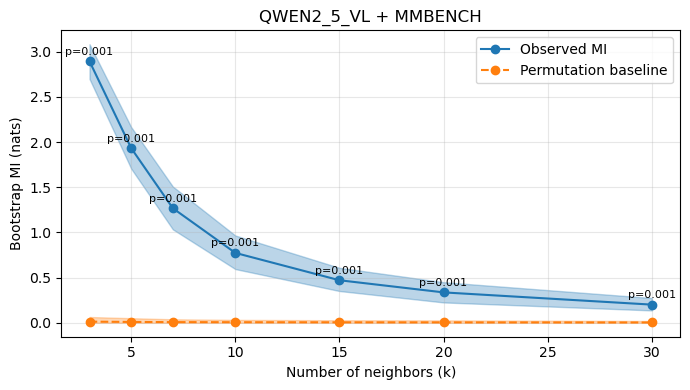

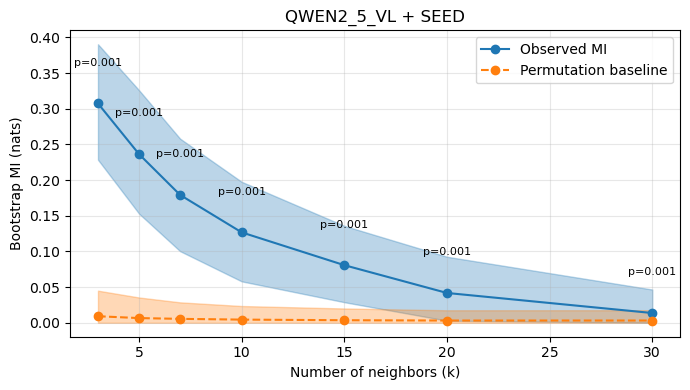

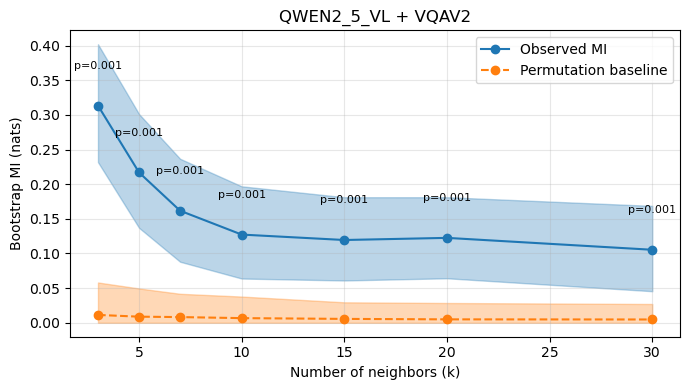

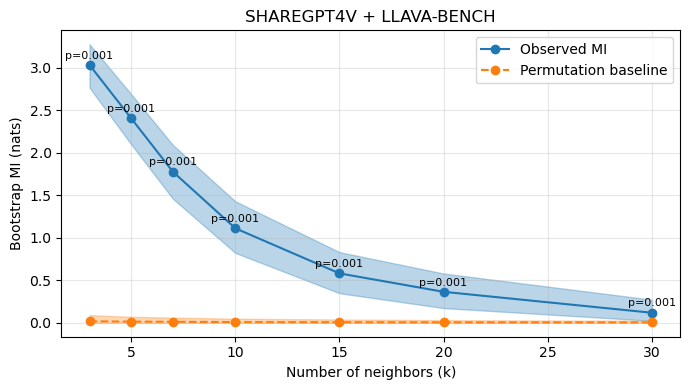

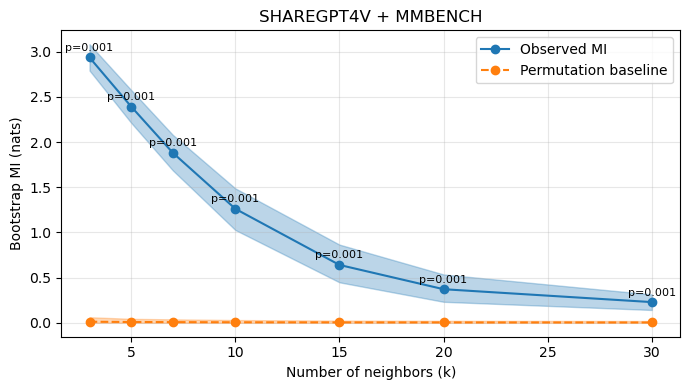

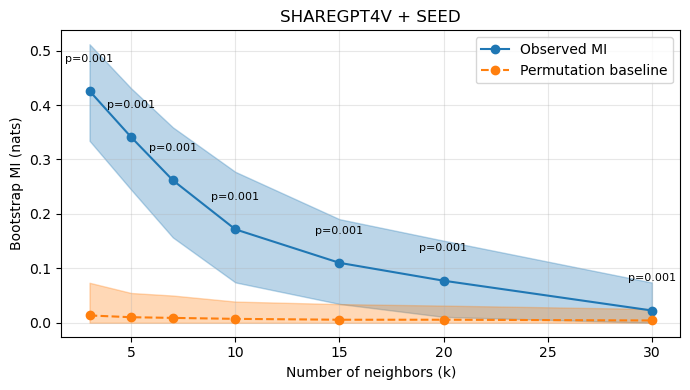

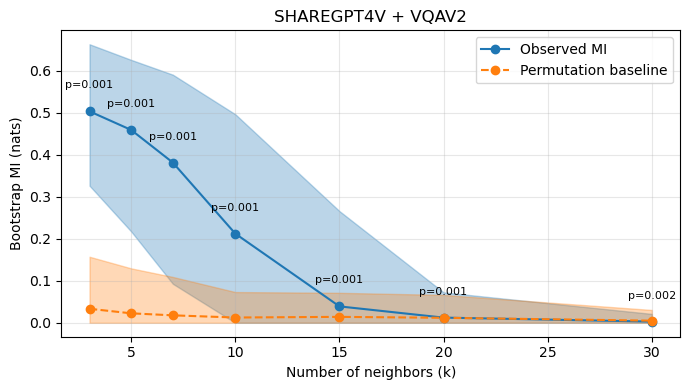

In [35]:
import matplotlib.pyplot as plt

for model, ds in zip(all_models, all_ds):
    plt.figure(figsize=(7, 4))
    plt.plot(
        k_vals,
        mi_data[model][ds]["means_obs"],
        "o-",
        label="Observed MI",
        color="tab:blue",
    )
    plt.fill_between(
        k_vals,
        mi_data[model][ds]["lows_obs"],
        mi_data[model][ds]["highs_obs"],
        color="tab:blue",
        alpha=0.3,
    )

    # Annotate p-values above each point
    for k, mean, p in zip(
        k_vals, mi_data[model][ds]["means_obs"], mi_data[model][ds]["pvals"]
    ):
        plt.text(k, mean + 0.05, f"p={p:.3f}", ha="center", va="bottom", fontsize=8)

    plt.plot(
        k_vals,
        mi_data[model][ds]["means_perm"],
        "o--",
        label="Permutation baseline",
        color="tab:orange",
    )

    plt.fill_between(
        k_vals,
        mi_data[model][ds]["lows_perm"],
        mi_data[model][ds]["highs_perm"],
        color="tab:orange",
        alpha=0.3,
    )

    plt.xlabel("Number of neighbors (k)")
    plt.ylabel("Bootstrap MI (nats)")
    plt.title(f"{model.upper()} + {ds.upper()}")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

**Notes on the outcomes**
- *p-values* after permutations might indicate significance
- Bootstrapped *confidence intervals* seem alright
  - Lot of uncertainty for small subsets (e.g., sharegpt4v on vqav2)
- Analysed measures while varying the number of neighbours k
  - MI decreases as the increase k, which is good
  - k=3 (default): MI is probably biased and inflated
  - k=10 : steepest decline (sometimes)
  - The 'correct' MI estimate should be somewhere between k=5 and k=10

**To report**
- Median MI between k=5 and k=10
- CI for MI

In [36]:
final_range = list(range(1, 4))
final_k_vals = k_vals[1:4]
for model, ds in zip(all_models, all_ds):
    # Get median MI
    final_mi = np.array(mi_data[model][ds]["means_obs"])[final_range]
    final_mi = np.median(final_mi).item()
    # Get corresponding index in 'main' list
    final_idx = np.where(np.array(mi_data[model][ds]["means_obs"]) == final_mi)[
        0
    ].item()
    # Get confidence interval for it
    final_low = mi_data[model][ds]["lows_obs"][final_idx]
    final_high = mi_data[model][ds]["highs_obs"][final_idx]

    print(
        f"{model.upper()} + {ds}: {final_mi:.3f} -- CI=({final_low:.3f}, {final_high:.3f})"
    )

INTERNVL2 + llava-bench: 3.187 -- CI=(2.942, 3.417)
INTERNVL2 + mmbench: 2.933 -- CI=(2.758, 3.104)
INTERNVL2 + seed: 0.366 -- CI=(0.309, 0.423)
INTERNVL2 + vqav2: 0.442 -- CI=(0.391, 0.494)
LLAVA-1.6 + llava-bench: 2.102 -- CI=(1.755, 2.434)
LLAVA-1.6 + mmbench: 2.196 -- CI=(1.993, 2.410)
LLAVA-1.6 + seed: 0.433 -- CI=(0.380, 0.486)
LLAVA-1.6 + vqav2: 0.445 -- CI=(0.394, 0.494)
QWEN2_5_VL + llava-bench: 2.683 -- CI=(2.398, 2.962)
QWEN2_5_VL + mmbench: 1.268 -- CI=(1.034, 1.508)
QWEN2_5_VL + seed: 0.179 -- CI=(0.100, 0.258)
QWEN2_5_VL + vqav2: 0.162 -- CI=(0.088, 0.237)
SHAREGPT4V + llava-bench: 1.778 -- CI=(1.459, 2.093)
SHAREGPT4V + mmbench: 1.882 -- CI=(1.687, 2.080)
SHAREGPT4V + seed: 0.262 -- CI=(0.157, 0.359)
SHAREGPT4V + vqav2: 0.381 -- CI=(0.093, 0.590)


**Moral of the story**
- On open-ended VQA datasets, we find strong dependency between model performance and the measured similarities
- On multiple-choice VQA datasets, we find weak to moderate dependency between model perfomance and the measured similarities

# Old code

In [ ]:
def permutation_pvalue(X, Y, n_perm=1000, random_state=0):
    rng = np.random.RandomState(random_state)
    mi_obs = mutual_info_regression(X, Y, random_state=random_state).item()
    mi_perm = []
    for i in range(n_perm):
        Yp = rng.permutation(Y)
        mi_perm.append(mutual_info_regression(X, Yp, random_state=random_state).item())
    mi_perm = np.array(mi_perm)
    pval = (np.sum(mi_perm >= mi_obs) + 1) / (n_perm + 1)
    return mi_obs, mi_perm, pval


def bootstrap_mi(X, Y, n_boot=500, random_state=0):
    rng = np.random.RandomState(random_state)
    mi_boot = []
    n = len(X)
    for _ in range(n_boot):
        idx = rng.randint(0, n, size=n)  # sample with replacement
        mi_boot.append(
            mutual_info_regression(X[idx], Y[idx], random_state=random_state).item()
        )
    mi_boot = np.array(mi_boot)
    lo, hi = np.percentile(mi_boot, [2.5, 97.5])
    return mi_boot, (lo, hi)


def search_k(X, Y, k_vals, random_state=0):
    mi_k = {}
    for k in k_vals:
        mi_k[k] = mutual_info_regression(
            X, Y, n_neighbors=k, random_state=random_state
        ).item()
    return mi_k


print(
    "\t\t\t\t = MI observed (nats) = \t = Perm p-value = \t = Bootstrap 95% CI (nats) ="
)
k_vals = [3, 5, 7, 10, 20]
for model, ds in zip(all_models, all_ds):
    if ds in OPEN_DATASETS:
        x = np.array(corr_input[model][ds]["cosine"]).reshape(-1, 1)
        y = np.array(corr_input[model][ds]["outcome"])
        mi_obs, mi_perm, pval = permutation_pvalue(x, y, n_perm=1000)
        mi_boot, ci = bootstrap_mi(x, y, n_boot=1000)
        mi_k = search_k(x, y, k_vals)
        print(
            f"{model} on {ds}     \t {mi_obs:.4f} \t\t\t {pval:.4f} \t\t\t [{ci[0].item():.4f}, {ci[1].item():.4f}]"
        )
        for k, mi in mi_k.items():
            print(f"\t\t\t k: {k} \t MI {mi:.4f}")